### Imports

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from bayesian_gpr import Atom, Scene
from bayesian_gpr.forward import render_atom
from bayesian_gpr.viz import plot_bscan

from quadratic_approximation import compute_quadratic_approximation

### Load the scene and define the atom

In [3]:
DATA_DIR = Path("data")
scene_path = DATA_DIR / "scene.npz"

scene = Scene.load(scene_path)

sigma = 0.02
lambda_r = 10.0

theta_0 = Atom(
    x0=25.0,
    depth=1.5,
    R=0.10,
    amplitude=0.8,
    eps_r=1.0,
)

parameter_names = ("x0", "depth", "R", "amplitude")

theta_0_vector = np.array(
    [
        theta_0.x0,
        theta_0.depth,
        theta_0.R,
        theta_0.amplitude,
    ],
    dtype=float,
)

theta_0_values = dict(zip(parameter_names, theta_0_vector))

print("Atom:")
print(theta_0)

print("\nParameter vector:")
print(theta_0_vector)

Atom:
Atom(x0=25.0, depth=1.5, R=0.1, eps_r=1.0, amplitude=0.8)

Parameter vector:
[25.   1.5  0.1  0.8]


### Generate and plot the noise-free data

Generated data shape: (2000, 5000)

Generated data:


<Axes: title={'center': 'Observed B-scan'}, xlabel='x (m)', ylabel='t (ns)'>

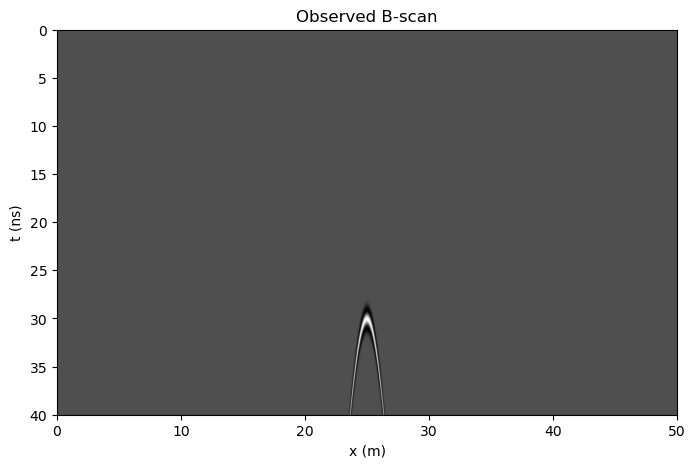

In [4]:
data = np.asarray(render_atom(theta_0, scene.grid, scene.wavelet, scene.soil), dtype=float)

print("Generated data shape:", data.shape)
print("\nGenerated data:")
plot_bscan(data, scene.grid, title="Observed B-scan")

### Define the unnormalised log posterior

In [5]:
def make_atom(
    *,
    x0: float,
    depth: float,
    R: float,
    amplitude: float,
) -> Atom:
    """Construct an atom while keeping eps_r fixed."""
    return Atom(
        x0=float(x0),
        depth=float(depth),
        R=float(R),
        amplitude=float(amplitude),
        eps_r=float(theta_0.eps_r),
    )


def unnormalised_log_posterior(
    atom: Atom,
    data: np.ndarray,
    scene: Scene,
    sigma: float,
    lambda_r: float,
) -> float:
    """Evaluate the unnormalised log posterior for one atom."""

    # Parameter support.
    if atom.depth <= 0.0 or atom.R < 0.0:
        return -np.inf

    prediction = np.asarray(
        render_atom(atom, scene.grid, scene.wavelet, scene.soil),
        dtype=float,
    )

    residual = data - prediction

    log_likelihood = (
        -0.5 * np.sum(residual**2) / sigma**2
    )

    # Exponential prior on R, ignoring constants independent of theta.
    log_prior = -lambda_r * atom.R

    return float(log_likelihood + log_prior)


log_posterior_at_atom = unnormalised_log_posterior(
    theta_0,
    data,
    scene,
    sigma,
    lambda_r,
)

print("Unnormalised log posterior at theta_0:")
print(log_posterior_at_atom)

Unnormalised log posterior at theta_0:
-1.0


### Compute the quadratic approximation

In [6]:
quadratic_result = compute_quadratic_approximation(
    sigma=sigma,
    atom=theta_0,
    scene=scene,
    lambda_r=lambda_r,
)

approximate_mean = quadratic_result.mean
covariance = quadratic_result.covariance

variances = np.diag(covariance)

if np.any(variances < 0.0):
    raise ValueError(
        "The covariance has negative diagonal entries."
    )

standard_deviations = np.sqrt(variances)

print("Parameter order:")
print(parameter_names)

print("\nAtom:")
print(theta_0_vector)

print("\nApproximate Gaussian mean:")
print(approximate_mean)

print("\nApproximate standard deviations:")
for name, standard_deviation in zip(
    parameter_names,
    standard_deviations,
):
    print(f"{name:>10}: {standard_deviation:.10g}")

Parameter order:
('x0', 'depth', 'R', 'amplitude')

Atom:
[25.   1.5  0.1  0.8]

Approximate Gaussian mean:
[25.          1.49999997  0.09999954  0.79999978]

Approximate standard deviations:
        x0: 4.287895329e-05
     depth: 2.29528579e-05
         R: 0.0002145108498
 amplitude: 0.0007161868789


### Choose evaluation ranges around the atom

In [7]:
number_of_points = 101
number_of_standard_deviations = 5.0

parameter_grids = {}

for index, parameter_name in enumerate(parameter_names):
    centre = approximate_mean[index]
    half_width = (
        number_of_standard_deviations
        * standard_deviations[index]
    )

    lower = centre - half_width
    upper = centre + half_width

    if parameter_name == "depth":
        lower = max(lower, 1e-12)

    if parameter_name == "R":
        lower = max(lower, 0.0)

    parameter_grids[parameter_name] = np.linspace(
        lower,
        upper,
        number_of_points,
    )

print("Parameter grid ranges:\n")

for parameter_name in parameter_names:
    values = parameter_grids[parameter_name]

    print(
        f"{parameter_name:>10}: "
        f"[{values[0]:.10g}, {values[-1]:.10g}]"
    )

Parameter grid ranges:

        x0: [24.99978561, 25.00021439]
     depth: [1.499885202, 1.500114731]
         R: [0.0989269856, 0.1010720941]
 amplitude: [0.7964188456, 0.8035807144]


### Evaluate each one-dimensional posterior slices

In [8]:
def evaluate_posterior_slice(
    parameter_name: str,
    values: np.ndarray,
) -> np.ndarray:
    """Vary one parameter while fixing all others at theta_0."""

    base_parameters = {
        "x0": theta_0.x0,
        "depth": theta_0.depth,
        "R": theta_0.R,
        "amplitude": theta_0.amplitude,
    }

    log_posterior_values = np.empty(
        values.shape,
        dtype=float,
    )

    for index, value in enumerate(values):
        parameters = base_parameters.copy()
        parameters[parameter_name] = float(value)

        candidate_atom = make_atom(**parameters)

        log_posterior_values[index] = (
            unnormalised_log_posterior(
                candidate_atom,
                data,
                scene,
                sigma,
                lambda_r,
            )
        )

    return log_posterior_values


log_posterior_slices = {}

for parameter_name in parameter_names:
    print(f"Evaluating {parameter_name} slice...")

    log_posterior_slices[parameter_name] = (
        evaluate_posterior_slice(
            parameter_name,
            parameter_grids[parameter_name],
        )
    )

print("Done.")

Evaluating x0 slice...
Evaluating depth slice...
Evaluating R slice...
Evaluating amplitude slice...
Done.


### Plot the relative unnormalised posterior slices

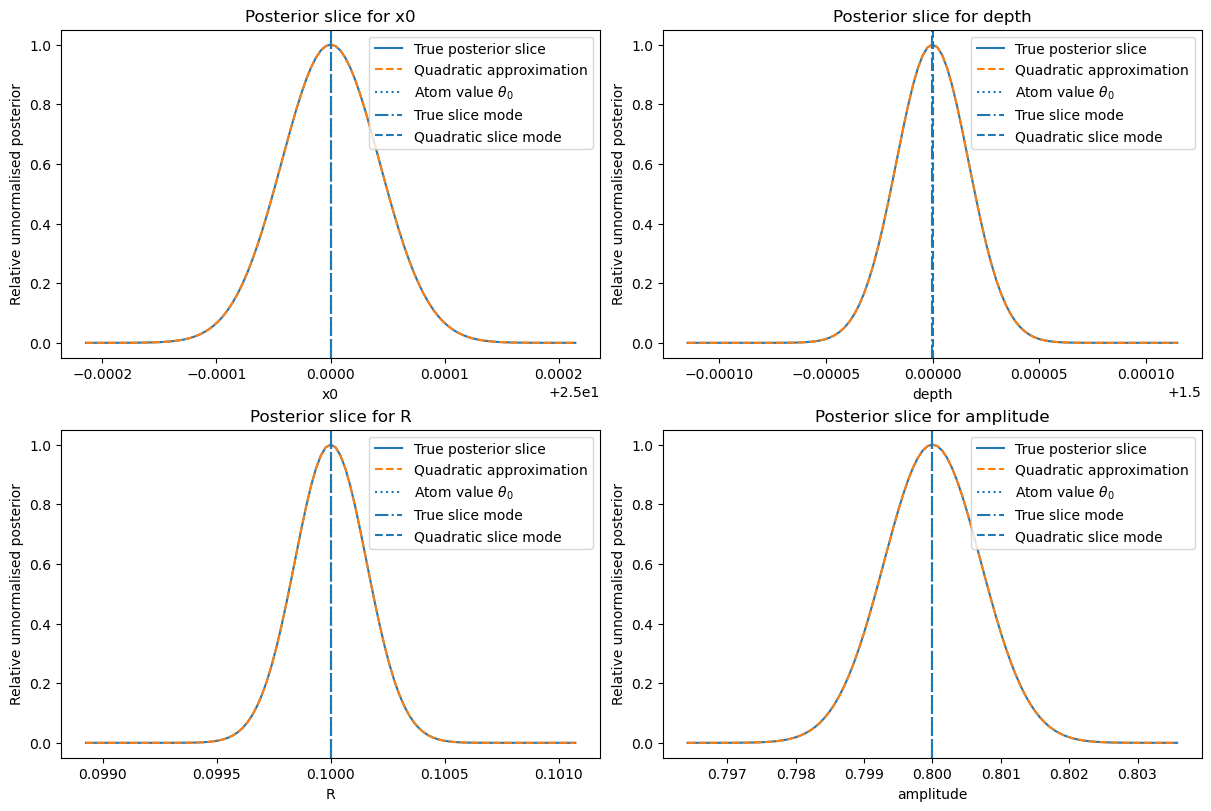

In [9]:
figure, axes = plt.subplots(
    2,
    2,
    figsize=(12, 8),
    constrained_layout=True,
)

g = quadratic_result.gradient_log_posterior
P = quadratic_result.precision

for parameter_index, (
    axis,
    parameter_name,
) in enumerate(zip(axes.flat, parameter_names)):

    values = parameter_grids[parameter_name]
    true_log_values = log_posterior_slices[parameter_name]

    # -------------------------------------------------------------
    # True posterior slice
    # -------------------------------------------------------------
    finite = np.isfinite(true_log_values)

    true_relative_posterior = np.zeros_like(
        true_log_values,
        dtype=float,
    )

    true_relative_posterior[finite] = np.exp(
        true_log_values[finite]
        - np.max(true_log_values[finite])
    )

    # -------------------------------------------------------------
    # Quadratic-approximation slice
    #
    # Only parameter i varies, so
    #
    #   delta = theta - theta_0
    #
    # has just one nonzero component. Therefore,
    #
    #   q(theta) - q(theta_0)
    #       = g_i * delta_i - 0.5 * P_ii * delta_i**2.
    # -------------------------------------------------------------
    delta = values - theta_0_vector[parameter_index]

    quadratic_log_values = (
        g[parameter_index] * delta
        - 0.5
        * P[parameter_index, parameter_index]
        * delta**2
    )

    quadratic_relative_posterior = np.exp(
        quadratic_log_values
        - np.max(quadratic_log_values)
    )

    # Grid-based mode of the true posterior slice.
    slice_mode_index = np.argmax(true_log_values)
    slice_mode = values[slice_mode_index]

    # Exact mode of the quadratic slice with all other parameters
    # fixed at theta_0.
    quadratic_slice_mode = (
        theta_0_vector[parameter_index]
        + g[parameter_index]
        / P[parameter_index, parameter_index]
    )

    # -------------------------------------------------------------
    # Plot
    # -------------------------------------------------------------
    axis.plot(
        values,
        true_relative_posterior,
        label="True posterior slice",
    )

    axis.plot(
        values,
        quadratic_relative_posterior,
        linestyle="--",
        label="Quadratic approximation",
    )

    axis.axvline(
        theta_0_vector[parameter_index],
        linestyle=":",
        label=r"Atom value $\theta_0$",
    )

    axis.axvline(
        slice_mode,
        linestyle="-.",
        label="True slice mode",
    )

    axis.axvline(
        quadratic_slice_mode,
        linestyle="--",
        label="Quadratic slice mode",
    )

    axis.set_xlabel(parameter_name)
    axis.set_ylabel("Relative unnormalised posterior")
    axis.set_title(f"Posterior slice for {parameter_name}")
    axis.legend()

plt.show()

### Plot the relative log-posterior slices

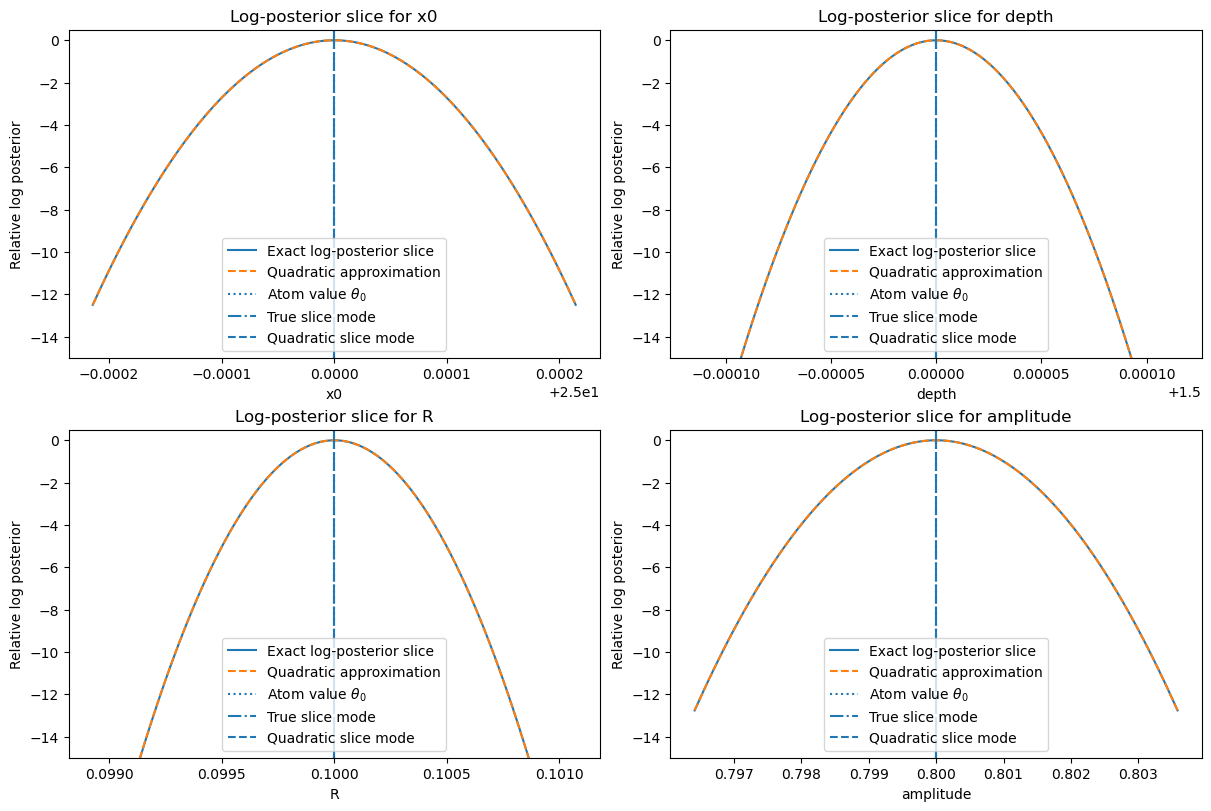

In [10]:
figure, axes = plt.subplots(
    2,
    2,
    figsize=(12, 8),
    constrained_layout=True,
)

g = quadratic_result.gradient_log_posterior
P = quadratic_result.precision

for parameter_index, (
    axis,
    parameter_name,
) in enumerate(zip(axes.flat, parameter_names)):

    values = parameter_grids[parameter_name]
    true_log_values = log_posterior_slices[parameter_name]

    # Relative true log-posterior slice.
    relative_log_posterior = (
        true_log_values - np.max(true_log_values)
    )

    # Quadratic approximation along the same 1D slice.
    delta = values - theta_0_vector[parameter_index]

    quadratic_log_values = (
        g[parameter_index] * delta
        - 0.5
        * P[parameter_index, parameter_index]
        * delta**2
    )

    relative_quadratic_log_posterior = (
        quadratic_log_values - np.max(quadratic_log_values)
    )

    # Modes.
    slice_mode_index = np.argmax(true_log_values)
    slice_mode = values[slice_mode_index]

    quadratic_slice_mode = (
        theta_0_vector[parameter_index]
        + g[parameter_index]
        / P[parameter_index, parameter_index]
    )

    # Plot both curves.
    axis.plot(
        values,
        relative_log_posterior,
        label="Exact log-posterior slice",
    )

    axis.plot(
        values,
        relative_quadratic_log_posterior,
        linestyle="--",
        label="Quadratic approximation",
    )

    axis.axvline(
        theta_0_vector[parameter_index],
        linestyle=":",
        label=r"Atom value $\theta_0$",
    )

    axis.axvline(
        slice_mode,
        linestyle="-.",
        label="True slice mode",
    )

    axis.axvline(
        quadratic_slice_mode,
        linestyle="--",
        label="Quadratic slice mode",
    )

    axis.set_xlabel(parameter_name)
    axis.set_ylabel("Relative log posterior")
    axis.set_title(
        f"Log-posterior slice for {parameter_name}"
    )
    axis.set_ylim(-15.0, 0.5)
    axis.legend()

plt.show()

### Print the slice modes and shifts

In [11]:
print("One-dimensional posterior slice modes:\n")

for parameter_index, parameter_name in enumerate(
    parameter_names
):
    values = parameter_grids[parameter_name]
    log_values = log_posterior_slices[parameter_name]

    slice_mode = values[np.argmax(log_values)]

    print(parameter_name)
    print(
        f"  Atom value:       "
        f"{theta_0_vector[parameter_index]:.12g}"
    )
    print(
        f"  Quadratic mean:   "
        f"{approximate_mean[parameter_index]:.12g}"
    )
    print(
        f"  Slice mode:       "
        f"{slice_mode:.12g}"
    )
    print(
        f"  Shift from atom:  "
        f"{slice_mode - theta_0_vector[parameter_index]:.6g}"
    )
    print()

One-dimensional posterior slice modes:

x0
  Atom value:       25
  Quadratic mean:   25
  Slice mode:       25
  Shift from atom:  0

depth
  Atom value:       1.5
  Quadratic mean:   1.49999996677
  Slice mode:       1.49999996677
  Shift from atom:  -3.32322e-08

R
  Atom value:       0.1
  Quadratic mean:   0.099999539851
  Slice mode:       0.099999539851
  Shift from atom:  -4.60149e-07

amplitude
  Atom value:       0.8
  Quadratic mean:   0.79999977997
  Slice mode:       0.79999977997
  Shift from atom:  -2.2003e-07



### Difference between exact and quadratic log-posterior slices

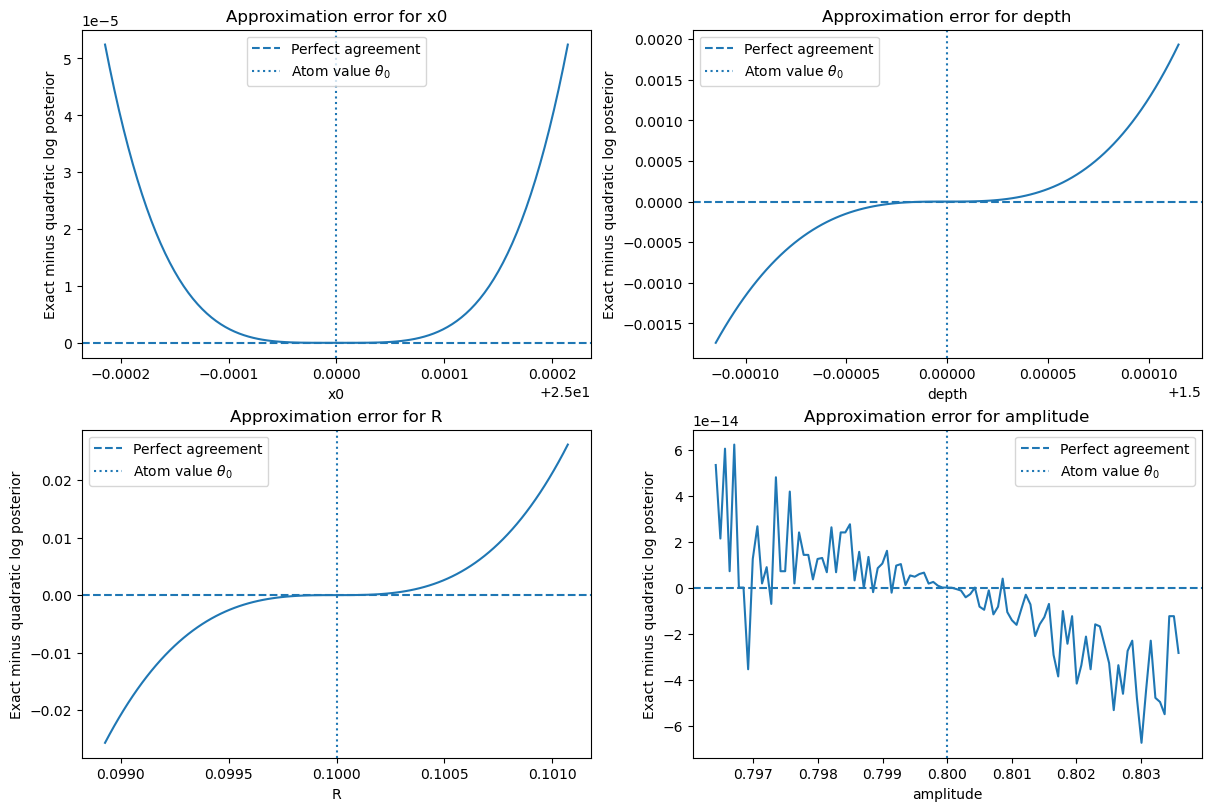

In [12]:
figure, axes = plt.subplots(
    2,
    2,
    figsize=(12, 8),
    constrained_layout=True,
)

g = quadratic_result.gradient_log_posterior
P = quadratic_result.precision

for parameter_index, (
    axis,
    parameter_name,
) in enumerate(zip(axes.flat, parameter_names)):

    values = parameter_grids[parameter_name]
    true_log_values = log_posterior_slices[parameter_name]

    # Exact log posterior relative to its maximum.
    relative_true_log_values = (
        true_log_values - np.max(true_log_values)
    )

    # Quadratic log posterior along the same one-dimensional slice.
    delta = values - theta_0_vector[parameter_index]

    quadratic_log_values = (
        g[parameter_index] * delta
        - 0.5
        * P[parameter_index, parameter_index]
        * delta**2
    )

    relative_quadratic_log_values = (
        quadratic_log_values
        - np.max(quadratic_log_values)
    )

    difference = (
        relative_true_log_values
        - relative_quadratic_log_values
    )

    axis.plot(values, difference)

    axis.axhline(
        0.0,
        linestyle="--",
        label="Perfect agreement",
    )

    axis.axvline(
        theta_0_vector[parameter_index],
        linestyle=":",
        label=r"Atom value $\theta_0$",
    )

    axis.set_xlabel(parameter_name)
    axis.set_ylabel(
        "Exact minus quadratic log posterior"
    )
    axis.set_title(
        f"Approximation error for {parameter_name}"
    )
    axis.legend()

plt.show()

### Exact and quadratic log posterior along a random direction

Random direction:
        x0: 8.068693683e-06
     depth: -3.782560758e-06
         R: 0.0001032071327
 amplitude: 0.0004254601596


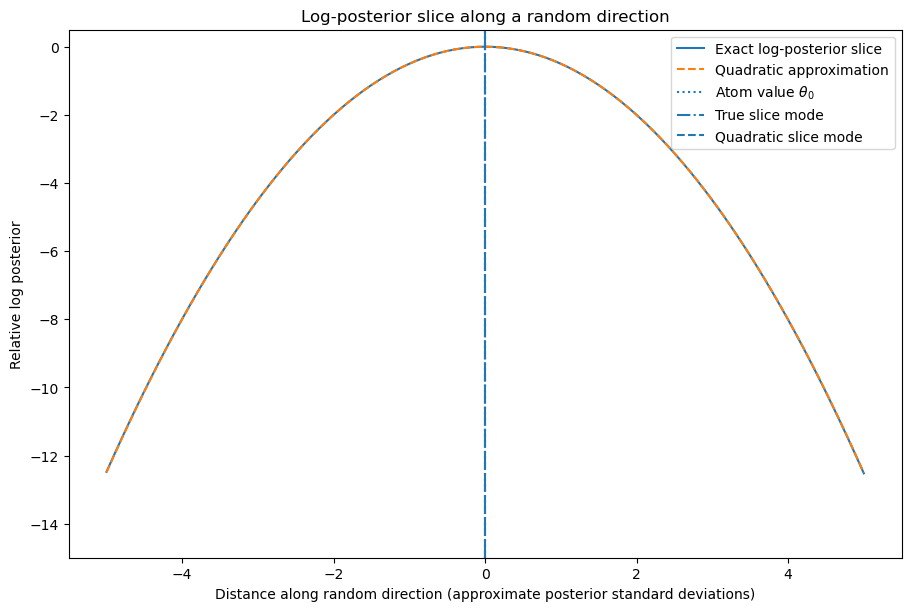

In [13]:
rng = np.random.default_rng(seed=42)

g = quadratic_result.gradient_log_posterior
P = quadratic_result.precision
covariance = quadratic_result.covariance

# Generate a random direction in whitened coordinates.
z = rng.normal(size=len(parameter_names))
z /= np.linalg.norm(z)

# Transform it into the original parameter coordinates.
eigenvalues, eigenvectors = np.linalg.eigh(covariance)
eigenvalues = np.maximum(eigenvalues, 0.0)

covariance_sqrt = (
    eigenvectors
    @ np.diag(np.sqrt(eigenvalues))
    @ eigenvectors.T
)

direction = covariance_sqrt @ z

# Normalize so that one unit of t corresponds to one approximate
# posterior standard deviation along this direction.
direction /= np.sqrt(direction @ P @ direction)

print("Random direction:")
for name, component in zip(parameter_names, direction):
    print(f"{name:>10}: {component:.10g}")

# Evaluate from -5 to +5 approximate posterior standard deviations.
t_values = np.linspace(-5.0, 5.0, 101)

exact_log_values = np.empty_like(t_values)

for index, t in enumerate(t_values):
    theta = theta_0_vector + t * direction

    candidate_atom = make_atom(
        x0=theta[0],
        depth=theta[1],
        R=theta[2],
        amplitude=theta[3],
    )

    exact_log_values[index] = unnormalised_log_posterior(
        candidate_atom,
        data,
        scene,
        sigma,
        lambda_r,
    )

# Relative true log-posterior slice.
relative_log_posterior = (
    exact_log_values - np.max(exact_log_values)
)

# Quadratic approximation along the same random direction.
quadratic_log_values = (
    t_values * (g @ direction)
    - 0.5
    * (direction @ P @ direction)
    * t_values**2
)

relative_quadratic_log_posterior = (
    quadratic_log_values - np.max(quadratic_log_values)
)

# Modes.
slice_mode_index = np.argmax(exact_log_values)
slice_mode = t_values[slice_mode_index]

quadratic_slice_mode = (
    (g @ direction)
    / (direction @ P @ direction)
)

# Plot both curves.
figure, axis = plt.subplots(
    figsize=(9, 6),
    constrained_layout=True,
)

axis.plot(
    t_values,
    relative_log_posterior,
    label="Exact log-posterior slice",
)

axis.plot(
    t_values,
    relative_quadratic_log_posterior,
    linestyle="--",
    label="Quadratic approximation",
)

axis.axvline(
    0.0,
    linestyle=":",
    label=r"Atom value $\theta_0$",
)

axis.axvline(
    slice_mode,
    linestyle="-.",
    label="True slice mode",
)

axis.axvline(
    quadratic_slice_mode,
    linestyle="--",
    label="Quadratic slice mode",
)

axis.set_xlabel(
    "Distance along random direction "
    "(approximate posterior standard deviations)"
)
axis.set_ylabel("Relative log posterior")
axis.set_title(
    "Log-posterior slice along a random direction"
)
axis.set_ylim(-15.0, 0.5)
axis.legend()

plt.show()

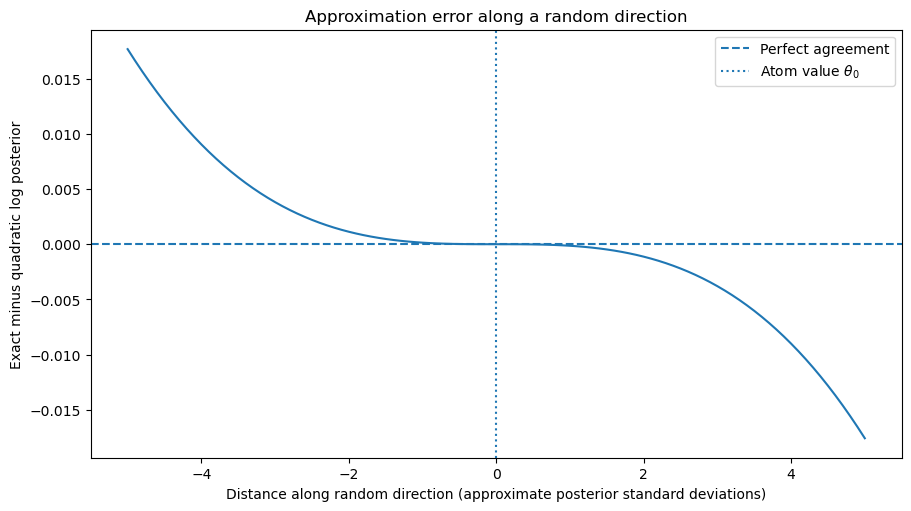

Maximum absolute difference: 0.017669424150129842


In [14]:
# Exact log posterior relative to its maximum.
relative_true_log_values = (
    exact_log_values - np.max(exact_log_values)
)

# Quadratic log posterior relative to its maximum.
relative_quadratic_log_values = (
    quadratic_log_values - np.max(quadratic_log_values)
)

difference = (
    relative_true_log_values
    - relative_quadratic_log_values
)

figure, axis = plt.subplots(
    figsize=(9, 5),
    constrained_layout=True,
)

axis.plot(
    t_values,
    difference,
)

axis.axhline(
    0.0,
    linestyle="--",
    label="Perfect agreement",
)

axis.axvline(
    0.0,
    linestyle=":",
    label=r"Atom value $\theta_0$",
)

axis.set_xlabel(
    "Distance along random direction "
    "(approximate posterior standard deviations)"
)
axis.set_ylabel(
    "Exact minus quadratic log posterior"
)
axis.set_title(
    "Approximation error along a random direction"
)
axis.legend()

plt.show()

print(
    "Maximum absolute difference:",
    np.max(np.abs(difference)),
)

### Exact and quadratic log posterior along precision eigenvectors

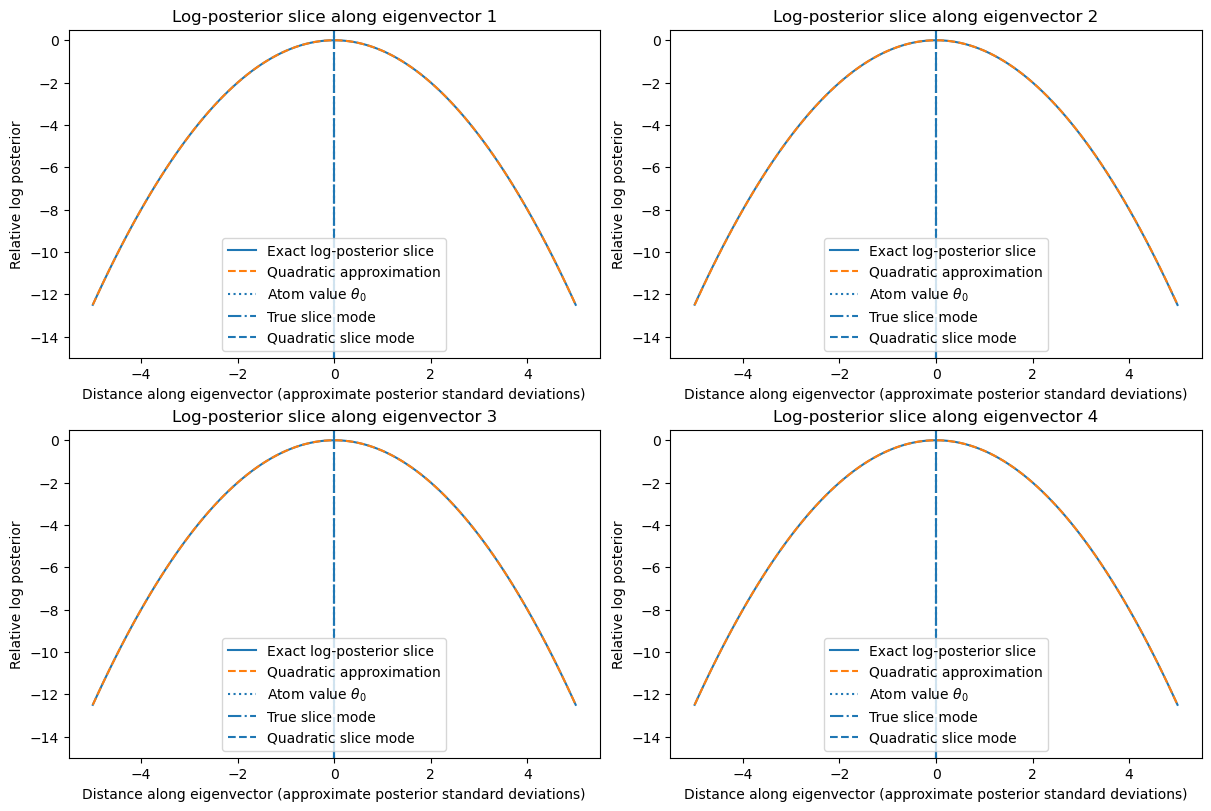

In [15]:
g = quadratic_result.gradient_log_posterior
P = quadratic_result.precision

# Precision eigenvalues are returned in ascending order.
eigenvalues, eigenvectors = np.linalg.eigh(P)

t_values = np.linspace(-5.0, 5.0, 101)

figure, axes = plt.subplots(
    2,
    2,
    figsize=(12, 8),
    constrained_layout=True,
)

for eigenvector_index, axis in enumerate(axes.flat):
    eigenvalue = eigenvalues[eigenvector_index]
    eigenvector = eigenvectors[:, eigenvector_index]

    if eigenvalue <= 0.0:
        raise ValueError(
            f"Precision eigenvalue {eigenvector_index} is not positive: "
            f"{eigenvalue}"
        )

    # Scale so that one unit of t is one approximate posterior
    # standard deviation along this eigenvector.
    direction = eigenvector / np.sqrt(eigenvalue)

    true_log_values = np.empty_like(t_values)

    for point_index, t in enumerate(t_values):
        theta = theta_0_vector + t * direction

        candidate_atom = make_atom(
            x0=theta[0],
            depth=theta[1],
            R=theta[2],
            amplitude=theta[3],
        )

        true_log_values[point_index] = (
            unnormalised_log_posterior(
                candidate_atom,
                data,
                scene,
                sigma,
                lambda_r,
            )
        )

    # Relative true log-posterior slice.
    finite = np.isfinite(true_log_values)

    relative_log_posterior = np.full_like(
        true_log_values,
        np.nan,
        dtype=float,
    )

    relative_log_posterior[finite] = (
        true_log_values[finite]
        - np.max(true_log_values[finite])
    )

    # Quadratic approximation along the same eigenvector direction.
    quadratic_log_values = (
        t_values * (g @ direction)
        - 0.5
        * (direction @ P @ direction)
        * t_values**2
    )

    relative_quadratic_log_posterior = (
        quadratic_log_values
        - np.max(quadratic_log_values)
    )

    # Modes.
    slice_mode_index = np.nanargmax(
        relative_log_posterior
    )
    slice_mode = t_values[slice_mode_index]

    quadratic_slice_mode = (
        (g @ direction)
        / (direction @ P @ direction)
    )

    # Plot both curves.
    axis.plot(
        t_values,
        relative_log_posterior,
        label="Exact log-posterior slice",
    )

    axis.plot(
        t_values,
        relative_quadratic_log_posterior,
        linestyle="--",
        label="Quadratic approximation",
    )

    axis.axvline(
        0.0,
        linestyle=":",
        label=r"Atom value $\theta_0$",
    )

    axis.axvline(
        slice_mode,
        linestyle="-.",
        label="True slice mode",
    )

    axis.axvline(
        quadratic_slice_mode,
        linestyle="--",
        label="Quadratic slice mode",
    )

    axis.set_xlabel(
        "Distance along eigenvector "
        "(approximate posterior standard deviations)"
    )
    axis.set_ylabel("Relative log posterior")
    axis.set_title(
        f"Log-posterior slice along eigenvector "
        f"{eigenvector_index + 1}"
    )
    axis.set_ylim(-15.0, 0.5)
    axis.legend()

plt.show()

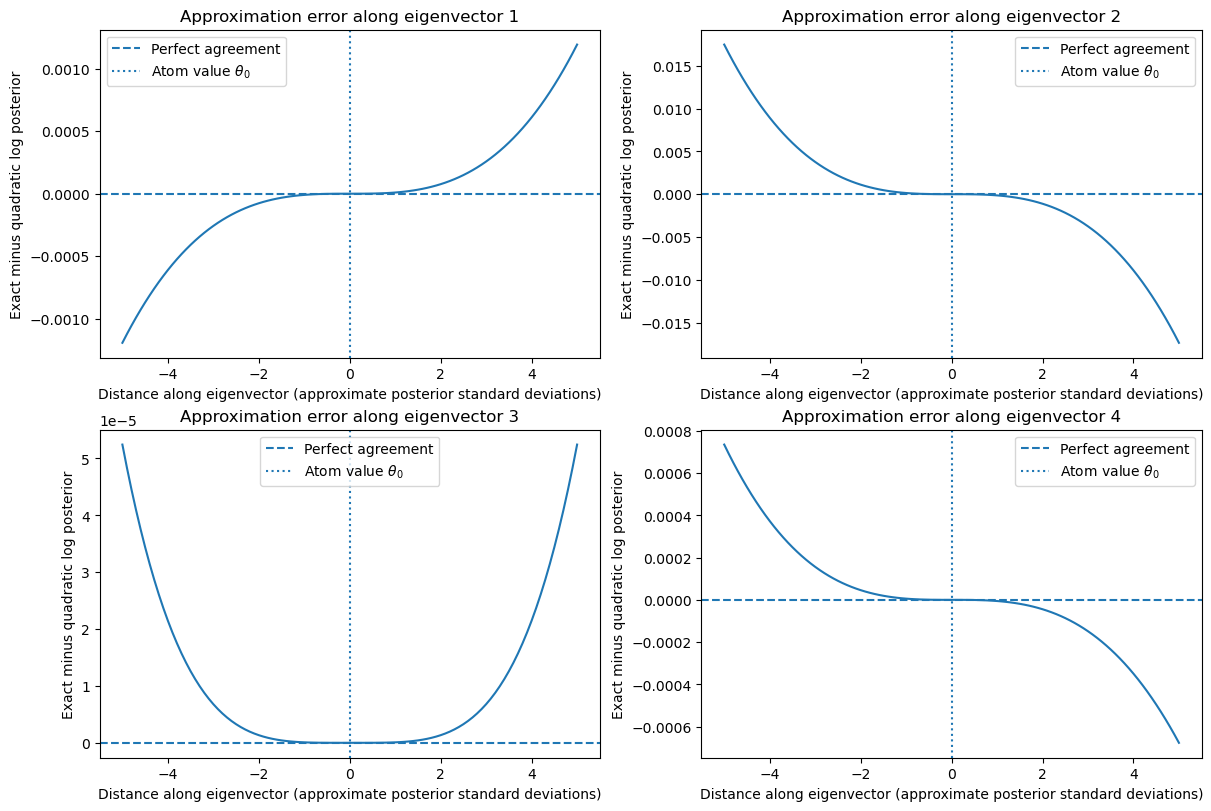

Maximum absolute differences:

Eigenvector 1: 0.00119154802417
Eigenvector 2: 0.0174842756227
Eigenvector 3: 5.24426893929e-05
Eigenvector 4: 0.000735040564534


In [16]:
figure_error, error_axes = plt.subplots(
    2,
    2,
    figsize=(12, 8),
    constrained_layout=True,
)

maximum_absolute_differences = []

for eigenvector_index, (
    source_axis,
    error_axis,
) in enumerate(zip(axes.flat, error_axes.flat)):

    # The first two plotted lines in each previous subplot are:
    #   1. exact relative log-posterior
    #   2. quadratic relative log-posterior
    exact_line = source_axis.lines[0]
    quadratic_line = source_axis.lines[1]

    direction_t_values = exact_line.get_xdata()
    relative_true_log_values = exact_line.get_ydata()
    relative_quadratic_log_values = quadratic_line.get_ydata()

    difference = (
        relative_true_log_values
        - relative_quadratic_log_values
    )

    maximum_absolute_differences.append(
        np.nanmax(np.abs(difference))
    )

    error_axis.plot(
        direction_t_values,
        difference,
    )

    error_axis.axhline(
        0.0,
        linestyle="--",
        label="Perfect agreement",
    )

    error_axis.axvline(
        0.0,
        linestyle=":",
        label=r"Atom value $\theta_0$",
    )

    error_axis.set_xlabel(
        "Distance along eigenvector "
        "(approximate posterior standard deviations)"
    )
    error_axis.set_ylabel(
        "Exact minus quadratic log posterior"
    )
    error_axis.set_title(
        f"Approximation error along eigenvector "
        f"{eigenvector_index + 1}"
    )
    error_axis.legend()

plt.show()

print("Maximum absolute differences:\n")

for eigenvector_index, maximum_difference in enumerate(
    maximum_absolute_differences
):
    print(
        f"Eigenvector {eigenvector_index + 1}: "
        f"{maximum_difference:.12g}"
    )

In [17]:
print("Precision eigenvectors:")
print("Parameter order:", parameter_names)
print()

for eigenvector_index in range(eigenvectors.shape[1]):
    print(
        f"Eigenvector {eigenvector_index + 1} "
        f"(eigenvalue = {eigenvalues[eigenvector_index]:.10g}):"
    )

    for parameter_name, component in zip(
        parameter_names,
        eigenvectors[:, eigenvector_index],
    ):
        print(f"  {parameter_name:>10}: {component:.10g}")

    print()

Precision eigenvectors:
Parameter order: ('x0', 'depth', 'R', 'amplitude')

Eigenvector 1 (eigenvalue = 1945655.789):
          x0: -4.202516979e-18
       depth: 0.003766805886
           R: 0.04699437771
   amplitude: 0.9988880516

Eigenvector 2 (eigenvalue = 22116753.73):
          x0: 1.019777759e-16
       depth: -0.07221070774
           R: -0.9962746019
   amplitude: 0.04714373006

Eigenvector 3 (eigenvalue = 543890720.7):
          x0: -1
       depth: -6.95711873e-17
           R: -9.728661966e-17
   amplitude: 6.321712709e-19

Eigenvector 4 (eigenvalue = 3505496396):
          x0: 6.235469661e-17
       depth: -0.9973822862
           R: 0.07230799444
   amplitude: 0.00035927576



### Define the n=2 unnormalised log posterior

In [18]:
def unnormalised_log_posterior_n2(
    atom_1: Atom,
    atom_2: Atom,
    data: np.ndarray,
    scene: Scene,
    sigma: float,
    lambda_r: float,
) -> float:
    """
    Evaluate the unnormalised log posterior on the n=2 subspace.

    The observed data are the noise-free data generated by theta_0:

        data = A(theta_0)

    and the two-atom forward model is

        A(theta_1, theta_2)
            = A(theta_1) + A(theta_2).
    """

    # Parameter support.
    for atom in (atom_1, atom_2):
        if atom.depth <= 0.0 or atom.R < 0.0:
            return -np.inf

    prediction_1 = np.asarray(
        render_atom(
            atom_1,
            scene.grid,
            scene.wavelet,
            scene.soil,
        ),
        dtype=float,
    )

    prediction_2 = np.asarray(
        render_atom(
            atom_2,
            scene.grid,
            scene.wavelet,
            scene.soil,
        ),
        dtype=float,
    )

    prediction = prediction_1 + prediction_2

    residual = data - prediction

    log_likelihood = (
        -0.5 * np.sum(residual**2) / sigma**2
    )

    # Independent exponential priors on the two radii.
    # Constants independent of theta_1, theta_2 are omitted.
    log_prior = -lambda_r * (atom_1.R + atom_2.R)

    return float(log_likelihood + log_prior)

### Define the proposed independent-Gaussian n=2 approximation

In [24]:
# Mean for each atom in the n=2 approximation:
# same x, depth and radius as the representative atom,
# but half the representative amplitude.

approximate_mean_n2 = approximate_mean.copy()

amplitude_index = parameter_names.index("amplitude")

approximate_mean_n2[amplitude_index] = (
    theta_0.amplitude / 2.0
)

print("n=1 approximate mean:")
print(approximate_mean)

print("\nn=2 per-atom approximate mean:")
print(approximate_mean_n2)

n=1 approximate mean:
[25.          1.49999997  0.09999954  0.79999978]

n=2 per-atom approximate mean:
[25.          1.49999997  0.09999954  0.4       ]


In [32]:
def log_gaussian_approximation_n2(
    theta_1: np.ndarray,
    theta_2: np.ndarray,
) -> float:
    """
    Unnormalised log density for

        q_2(theta_1, theta_2)
            = q(theta_1) q(theta_2),

    where both q distributions have:

        mean = approximate_mean_n2
        precision = n=1 precision matrix.
    """

    P = quadratic_result.precision

    delta_1 = (
        theta_1 - approximate_mean_n2
    )

    delta_2 = (
        theta_2 - approximate_mean_n2
    )

    return float(
        -0.5 * delta_1 @ P @ delta_1
        -0.5 * delta_2 @ P @ delta_2
    )

### Define the new n=2 Gaussian mean and 10-point grids

In [33]:
# =============================================================
# n=2 independent-Gaussian approximation:
#
# Each atom has the same covariance as the n=1 Gaussian,
# but the mean amplitude is halved.
# =============================================================

approximate_mean_n2 = approximate_mean.copy()

amplitude_index = parameter_names.index("amplitude")

approximate_mean_n2[amplitude_index] = (
    theta_0.amplitude / 2.0
)

print("n=1 Gaussian mean:")
print(approximate_mean)

print("\nn=2 Gaussian mean for EACH atom:")
print(approximate_mean_n2)


# -------------------------------------------------------------
# Construct 10-point grids centred at the new n=2 mean.
#
# Keep the same +/- 5 standard-deviation range as the n=1
# notebook.
# -------------------------------------------------------------

number_of_points_n2 = 10
number_of_standard_deviations_n2 = 5.0

parameter_grids_n2 = {}

for index, parameter_name in enumerate(parameter_names):

    centre = approximate_mean_n2[index]

    half_width = (
        number_of_standard_deviations_n2
        * standard_deviations[index]
    )

    lower = centre - half_width
    upper = centre + half_width

    # Respect parameter support.
    if parameter_name == "depth":
        lower = max(lower, 1e-12)

    if parameter_name == "R":
        lower = max(lower, 0.0)

    parameter_grids_n2[parameter_name] = np.linspace(
        lower,
        upper,
        number_of_points_n2,
    )


print("\nn=2 parameter grid ranges:\n")

for parameter_name in parameter_names:

    values = parameter_grids_n2[parameter_name]

    print(
        f"{parameter_name:>10}: "
        f"[{values[0]:.10g}, {values[-1]:.10g}]"
    )

n=1 Gaussian mean:
[25.          1.49999997  0.09999954  0.79999978]

n=2 Gaussian mean for EACH atom:
[25.          1.49999997  0.09999954  0.4       ]

n=2 parameter grid ranges:

        x0: [24.99978561, 25.00021439]
     depth: [1.499885202, 1.500114731]
         R: [0.0989269856, 0.1010720941]
 amplitude: [0.3964190656, 0.4035809344]


### Evaluate the 10×10 heatmap grids

In [34]:
def evaluate_n2_parameter_grid(
    parameter_name: str,
    values: np.ndarray,
):
    """
    Evaluate a 2D slice through the n=2 posterior.

    x-axis:
        chosen parameter of atom 1

    y-axis:
        chosen parameter of atom 2

    Every other parameter of BOTH atoms is fixed at the
    new n=2 Gaussian mean.
    """

    parameter_index = (
        parameter_names.index(parameter_name)
    )

    n_values = len(values)

    true_log_grid = np.empty(
        (n_values, n_values),
        dtype=float,
    )

    approximate_log_grid = np.empty(
        (n_values, n_values),
        dtype=float,
    )

    for i, value_1 in enumerate(values):

        for j, value_2 in enumerate(values):

            # -----------------------------------------------------
            # Start both atoms at the new Gaussian mean.
            # -----------------------------------------------------

            theta_1 = approximate_mean_n2.copy()
            theta_2 = approximate_mean_n2.copy()

            # Vary the selected parameter independently.
            theta_1[parameter_index] = float(value_1)
            theta_2[parameter_index] = float(value_2)

            # -----------------------------------------------------
            # Construct atoms.
            # -----------------------------------------------------

            atom_1 = make_atom(
                x0=theta_1[0],
                depth=theta_1[1],
                R=theta_1[2],
                amplitude=theta_1[3],
            )

            atom_2 = make_atom(
                x0=theta_2[0],
                depth=theta_2[1],
                R=theta_2[2],
                amplitude=theta_2[3],
            )

            # -----------------------------------------------------
            # Exact posterior.
            #
            # j is the row -> atom 2/y-axis
            # i is the column -> atom 1/x-axis
            # -----------------------------------------------------

            true_log_grid[j, i] = (
                unnormalised_log_posterior_n2(
                    atom_1,
                    atom_2,
                    data,
                    scene,
                    sigma,
                    lambda_r,
                )
            )

            # -----------------------------------------------------
            # Independent-Gaussian approximation.
            # -----------------------------------------------------

            approximate_log_grid[j, i] = (
                log_gaussian_approximation_n2(
                    theta_1,
                    theta_2,
                )
            )

    return (
        true_log_grid,
        approximate_log_grid,
    )


true_log_grids_n2 = {}
approximate_log_grids_n2 = {}

for parameter_name in parameter_names:

    print(
        f"Evaluating 10 x 10 grid for "
        f"{parameter_name}..."
    )

    (
        true_log_grids_n2[parameter_name],
        approximate_log_grids_n2[parameter_name],
    ) = evaluate_n2_parameter_grid(
        parameter_name,
        parameter_grids_n2[parameter_name],
    )

print("Done.")

Evaluating 10 x 10 grid for x0...
Evaluating 10 x 10 grid for depth...
Evaluating 10 x 10 grid for R...
Evaluating 10 x 10 grid for amplitude...
Done.


### Exact n=2 posterior on usual scale

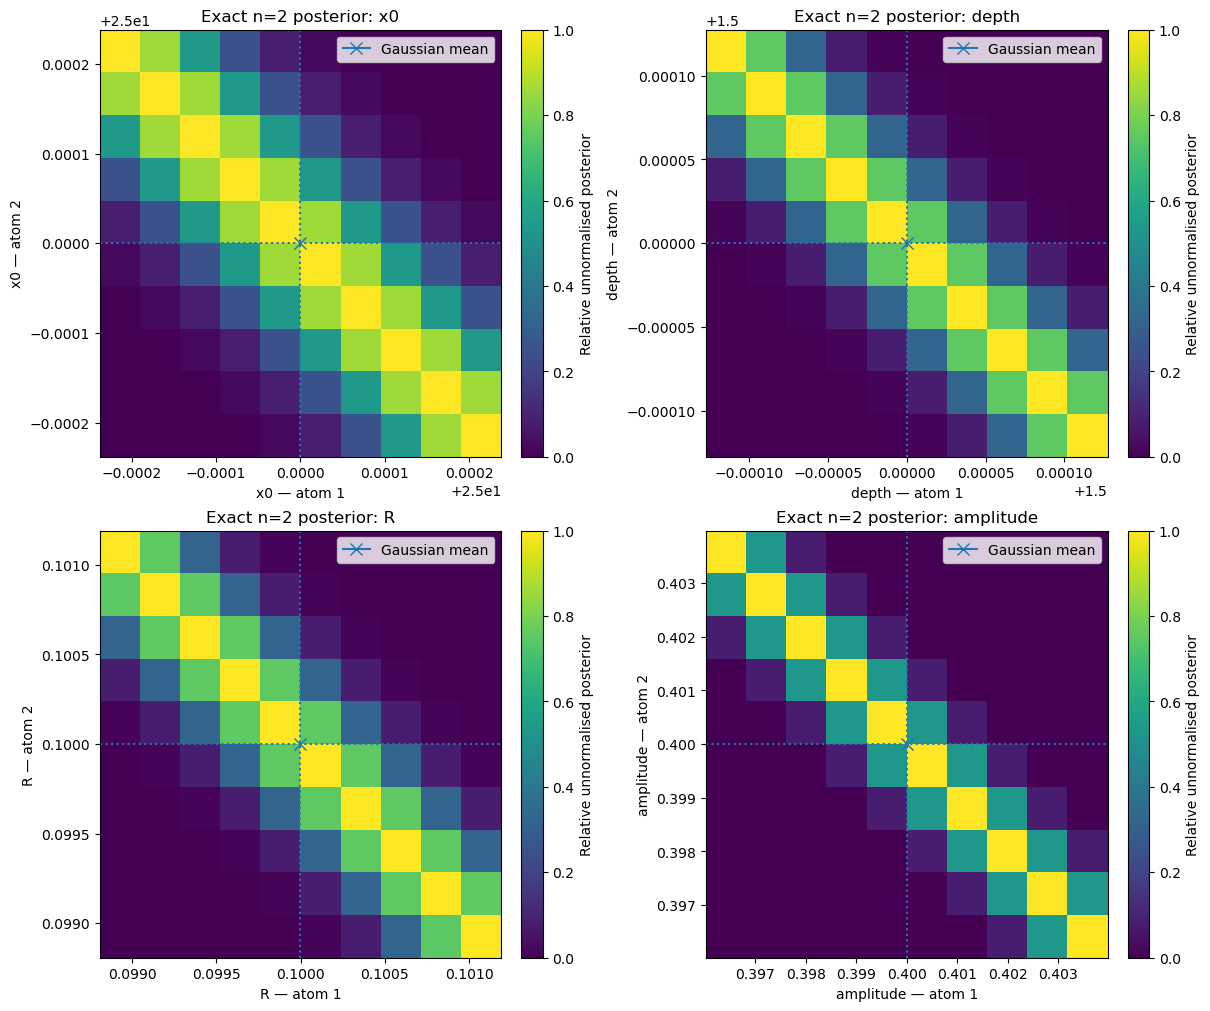

In [35]:
figure, axes = plt.subplots(
    2,
    2,
    figsize=(12, 10),
    constrained_layout=True,
)

for parameter_index, (
    axis,
    parameter_name,
) in enumerate(
    zip(axes.flat, parameter_names)
):

    values = (
        parameter_grids_n2[parameter_name]
    )

    log_grid = (
        true_log_grids_n2[parameter_name]
    )

    finite = np.isfinite(log_grid)

    relative_posterior = np.zeros_like(
        log_grid,
        dtype=float,
    )

    relative_posterior[finite] = np.exp(
        log_grid[finite]
        - np.max(log_grid[finite])
    )

    mesh = axis.pcolormesh(
        values,
        values,
        relative_posterior,
        shading="auto",
        vmin=0.0,
        vmax=1.0,
    )

    # New per-atom Gaussian mean.
    centre = (
        approximate_mean_n2[parameter_index]
    )

    axis.axvline(
        centre,
        linestyle=":",
    )

    axis.axhline(
        centre,
        linestyle=":",
    )

    axis.plot(
        centre,
        centre,
        marker="x",
        markersize=8,
        label="Gaussian mean",
    )

    axis.set_xlabel(
        f"{parameter_name} — atom 1"
    )

    axis.set_ylabel(
        f"{parameter_name} — atom 2"
    )

    axis.set_title(
        f"Exact n=2 posterior: "
        f"{parameter_name}"
    )

    axis.legend()

    figure.colorbar(
        mesh,
        ax=axis,
        label=(
            "Relative unnormalised posterior"
        ),
    )

plt.show()

### Independent-Gaussian approximation on usual scale

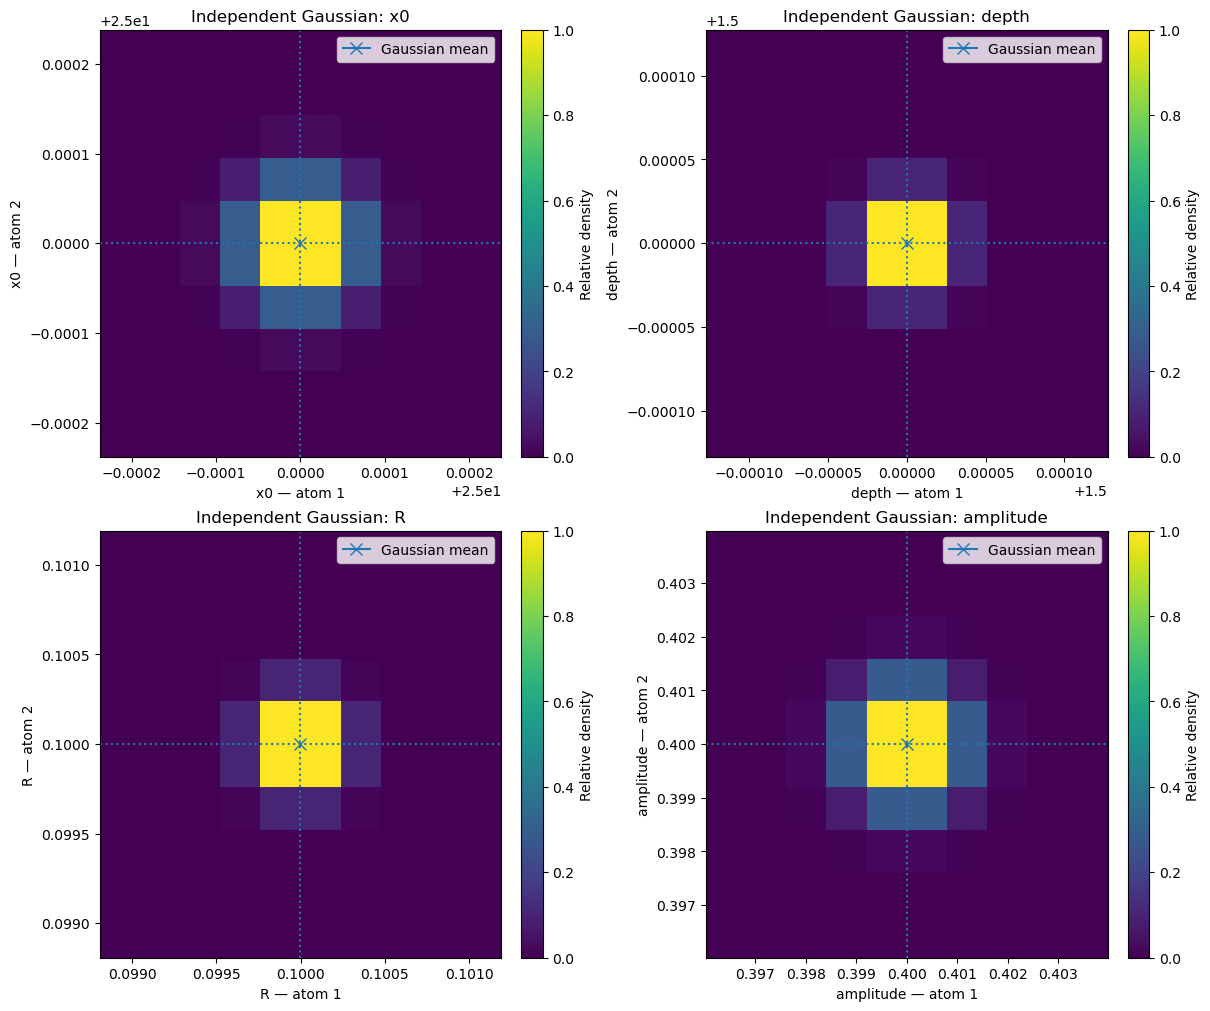

In [36]:
figure, axes = plt.subplots(
    2,
    2,
    figsize=(12, 10),
    constrained_layout=True,
)

for parameter_index, (
    axis,
    parameter_name,
) in enumerate(
    zip(axes.flat, parameter_names)
):

    values = (
        parameter_grids_n2[parameter_name]
    )

    log_grid = (
        approximate_log_grids_n2[
            parameter_name
        ]
    )

    relative_density = np.exp(
        log_grid - np.max(log_grid)
    )

    mesh = axis.pcolormesh(
        values,
        values,
        relative_density,
        shading="auto",
        vmin=0.0,
        vmax=1.0,
    )

    centre = (
        approximate_mean_n2[parameter_index]
    )

    axis.axvline(
        centre,
        linestyle=":",
    )

    axis.axhline(
        centre,
        linestyle=":",
    )

    axis.plot(
        centre,
        centre,
        marker="x",
        markersize=8,
        label="Gaussian mean",
    )

    axis.set_xlabel(
        f"{parameter_name} — atom 1"
    )

    axis.set_ylabel(
        f"{parameter_name} — atom 2"
    )

    axis.set_title(
        f"Independent Gaussian: "
        f"{parameter_name}"
    )

    axis.legend()

    figure.colorbar(
        mesh,
        ax=axis,
        label="Relative density",
    )

plt.show()

### Exact n=2 posterior on log scale

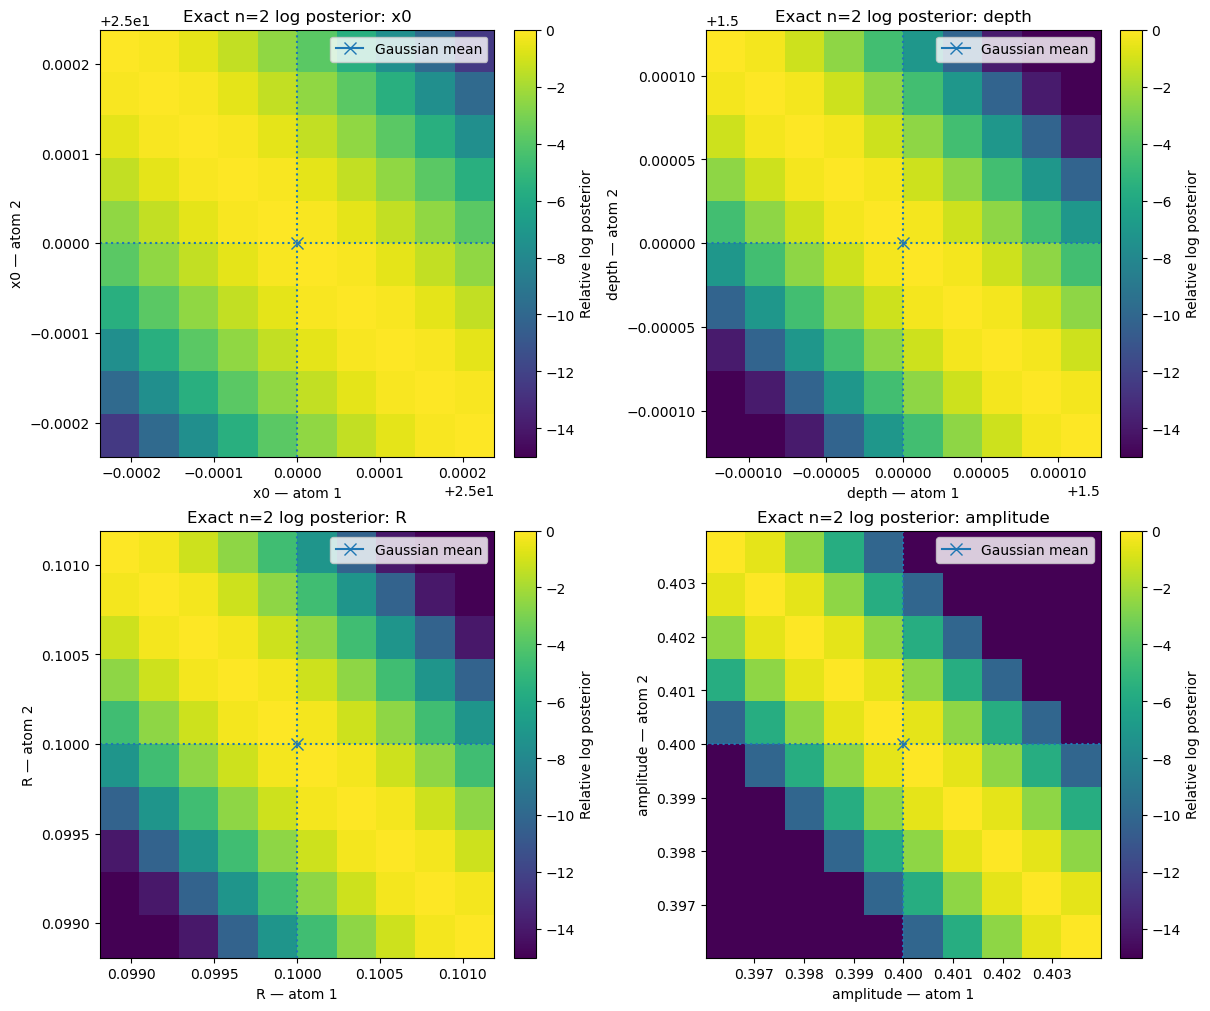

In [37]:
figure, axes = plt.subplots(
    2,
    2,
    figsize=(12, 10),
    constrained_layout=True,
)

for parameter_index, (
    axis,
    parameter_name,
) in enumerate(
    zip(axes.flat, parameter_names)
):

    values = (
        parameter_grids_n2[parameter_name]
    )

    log_grid = (
        true_log_grids_n2[parameter_name]
    )

    relative_log_grid = (
        log_grid - np.nanmax(log_grid)
    )

    mesh = axis.pcolormesh(
        values,
        values,
        relative_log_grid,
        shading="auto",
        vmin=-15.0,
        vmax=0.0,
    )

    centre = (
        approximate_mean_n2[parameter_index]
    )

    axis.axvline(
        centre,
        linestyle=":",
    )

    axis.axhline(
        centre,
        linestyle=":",
    )

    axis.plot(
        centre,
        centre,
        marker="x",
        markersize=8,
        label="Gaussian mean",
    )

    axis.set_xlabel(
        f"{parameter_name} — atom 1"
    )

    axis.set_ylabel(
        f"{parameter_name} — atom 2"
    )

    axis.set_title(
        f"Exact n=2 log posterior: "
        f"{parameter_name}"
    )

    axis.legend()

    figure.colorbar(
        mesh,
        ax=axis,
        label="Relative log posterior",
    )

plt.show()

### Independent Gaussian on log scale

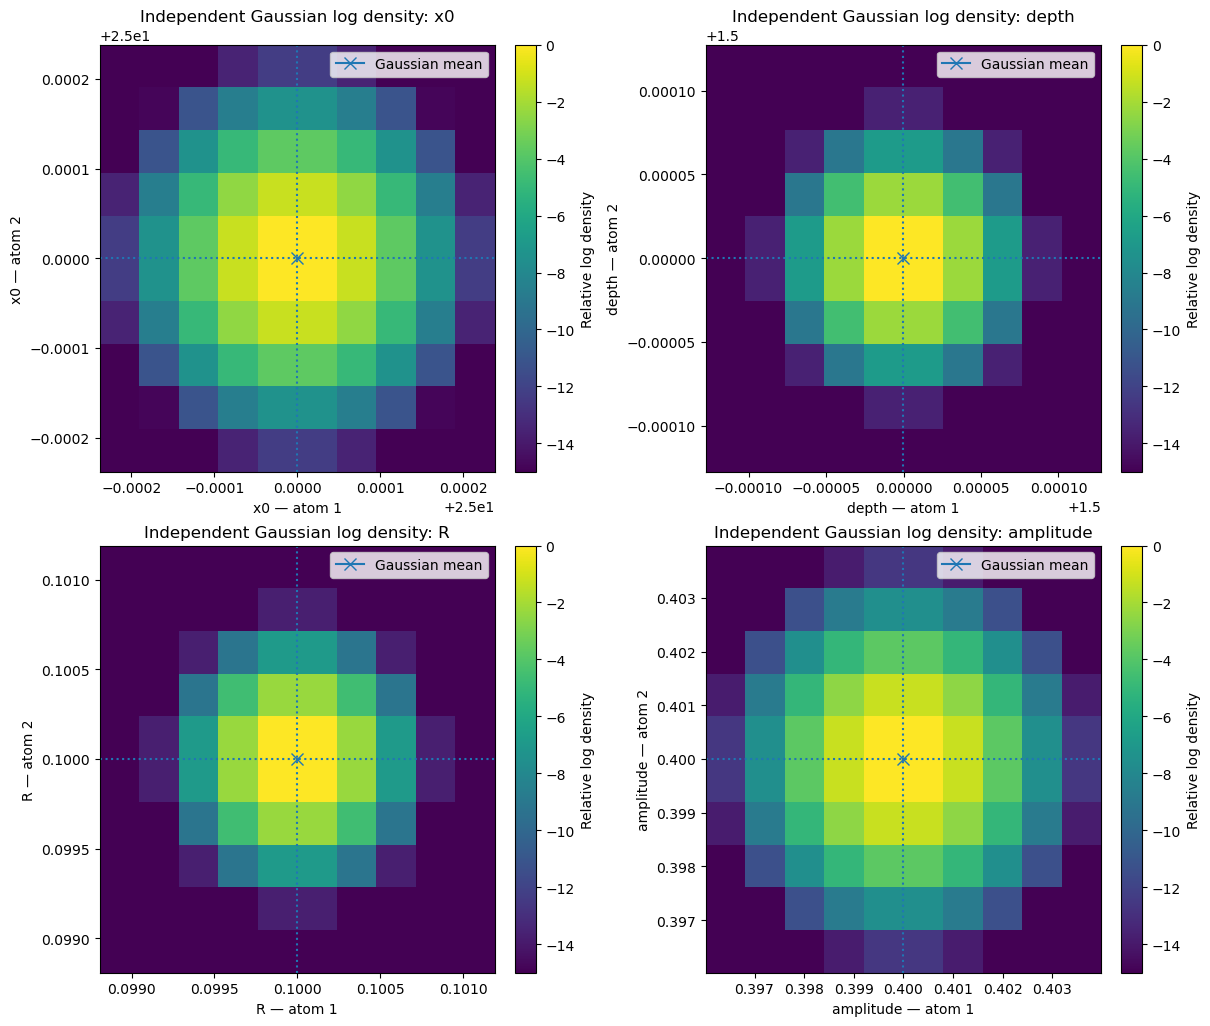

In [38]:
figure, axes = plt.subplots(
    2,
    2,
    figsize=(12, 10),
    constrained_layout=True,
)

for parameter_index, (
    axis,
    parameter_name,
) in enumerate(
    zip(axes.flat, parameter_names)
):

    values = (
        parameter_grids_n2[parameter_name]
    )

    log_grid = (
        approximate_log_grids_n2[
            parameter_name
        ]
    )

    relative_log_grid = (
        log_grid - np.max(log_grid)
    )

    mesh = axis.pcolormesh(
        values,
        values,
        relative_log_grid,
        shading="auto",
        vmin=-15.0,
        vmax=0.0,
    )

    centre = (
        approximate_mean_n2[parameter_index]
    )

    axis.axvline(
        centre,
        linestyle=":",
    )

    axis.axhline(
        centre,
        linestyle=":",
    )

    axis.plot(
        centre,
        centre,
        marker="x",
        markersize=8,
        label="Gaussian mean",
    )

    axis.set_xlabel(
        f"{parameter_name} — atom 1"
    )

    axis.set_ylabel(
        f"{parameter_name} — atom 2"
    )

    axis.set_title(
        f"Independent Gaussian log density: "
        f"{parameter_name}"
    )

    axis.legend()

    figure.colorbar(
        mesh,
        ax=axis,
        label="Relative log density",
    )

plt.show()

### Difference in relative log density

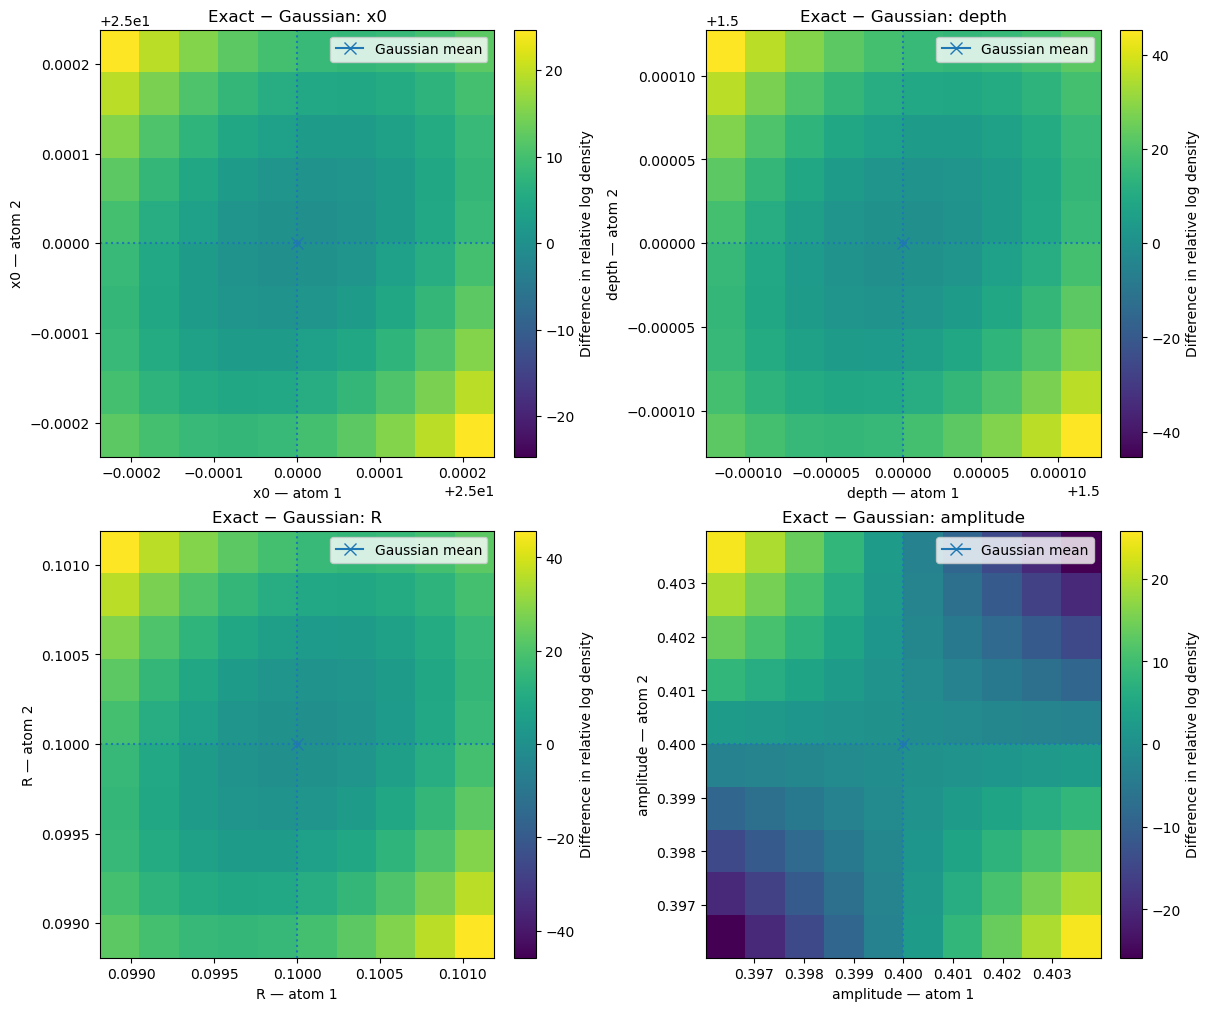

Maximum absolute differences in relative log density:

        x0: 24.6912058678
     depth: 45.3631228497
         R: 45.7695754627
 amplitude: 25.8483417853


In [39]:
figure, axes = plt.subplots(
    2,
    2,
    figsize=(12, 10),
    constrained_layout=True,
)

maximum_absolute_differences_n2 = {}

for parameter_index, (
    axis,
    parameter_name,
) in enumerate(
    zip(axes.flat, parameter_names)
):

    values = (
        parameter_grids_n2[parameter_name]
    )

    true_log_grid = (
        true_log_grids_n2[parameter_name]
    )

    approximate_log_grid = (
        approximate_log_grids_n2[
            parameter_name
        ]
    )

    relative_true_log_grid = (
        true_log_grid
        - np.nanmax(true_log_grid)
    )

    relative_approximate_log_grid = (
        approximate_log_grid
        - np.nanmax(approximate_log_grid)
    )

    difference = (
        relative_true_log_grid
        - relative_approximate_log_grid
    )

    finite = np.isfinite(difference)

    maximum_absolute_difference = (
        np.max(
            np.abs(difference[finite])
        )
    )

    maximum_absolute_differences_n2[
        parameter_name
    ] = maximum_absolute_difference

    # Use a symmetric colour scale around zero.
    difference_limit = (
        maximum_absolute_difference
    )

    if difference_limit == 0.0:
        difference_limit = 1.0

    mesh = axis.pcolormesh(
        values,
        values,
        difference,
        shading="auto",
        vmin=-difference_limit,
        vmax=difference_limit,
    )

    centre = (
        approximate_mean_n2[parameter_index]
    )

    axis.axvline(
        centre,
        linestyle=":",
    )

    axis.axhline(
        centre,
        linestyle=":",
    )

    axis.plot(
        centre,
        centre,
        marker="x",
        markersize=8,
        label="Gaussian mean",
    )

    axis.set_xlabel(
        f"{parameter_name} — atom 1"
    )

    axis.set_ylabel(
        f"{parameter_name} — atom 2"
    )

    axis.set_title(
        f"Exact − Gaussian: "
        f"{parameter_name}"
    )

    axis.legend()

    figure.colorbar(
        mesh,
        ax=axis,
        label="Difference in relative log density",
    )

plt.show()


print(
    "Maximum absolute differences "
    "in relative log density:\n"
)

for parameter_name in parameter_names:

    print(
        f"{parameter_name:>10}: "
        f"{maximum_absolute_differences_n2[parameter_name]:.12g}"
    )